## 1. Import des bibliothèques

In [ ]:
from pathlib import Path
import random
import hashlib

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import sys
import torch
from torchvision import models
from torchvision.io import read_image, ImageReadMode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import time
from contextlib import contextmanager
from threading import Event, Thread
import psutil
from torchvision.transforms.functional import equalize



In [40]:
debut_notebook = time.perf_counter()

In [41]:
dossier_dataset = Path("mri_dataset_brain_cancer_oc")

print("Le dossier existe :", dossier_dataset.is_dir())

Le dossier existe : True


## Étape 1 : import des données et exploration des images

Le dataset est organisé en deux répertoires : un avec labels et un sans label.

normal : image labellisée comme ne présentant pas de tumeur.
cancer : image labellisée comme présentant une tumeur cancéreuse.

Le fichier .txt décrit le contenu du dataset : **1 500 images**, au format **JPEG**, dont 100 étiquetées et 1 400 sans label.

Le code compte les images et affiche l'écart avec ce descriptif.

In [42]:
chemins_images = sorted(dossier_dataset.rglob("*.jpg"))

print("Nombre total d'images :", len(chemins_images))
print("Nombre annoncé dans le descriptif :", 1500)
print("Écart au descriptif :", len(chemins_images) - 1500)

Nombre total d'images : 1506
Nombre annoncé dans le descriptif : 1500
Écart au descriptif : 6


Comptons maintenant les images de chaque dossier.


In [43]:
dossiers = ["avec_labels/cancer", "avec_labels/normal", "sans_label"]
effectifs = []

for dossier in dossiers:
    fichiers = list((dossier_dataset / dossier).glob("*.jpg"))
    effectifs.append({
        "Dossier": dossier,
        "Nombre d'images": len(fichiers),
    })

tableau_effectifs = pd.DataFrame(effectifs)
display(tableau_effectifs)

,Dossier,Nombre d'images
0,avec_labels/cancer,50
1,avec_labels/normal,50
2,sans_label,1406


Ouverture d'une image et lecture de ses propriétés

In [44]:
chemin_exemple = chemins_images[0]

with Image.open(chemin_exemple) as image:
    print("Fichier :", chemin_exemple.name)
    print("Dossier :", chemin_exemple.parent.relative_to(dossier_dataset))
    print("Format :", image.format)
    print("Largeur :", image.width, "pixels")
    print("Hauteur :", image.height, "pixels")
    print("Mode de couleur :", image.mode)
    print("Canaux :", image.getbands())
    pixels = np.array(image)

print("Forme du tableau NumPy :", pixels.shape)

Fichier : 05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
Dossier : avec_labels/cancer
Format : JPEG
Largeur : 512 pixels
Hauteur : 512 pixels
Mode de couleur : RGB
Canaux : ('R', 'G', 'B')
Forme du tableau NumPy : (512, 512, 3)


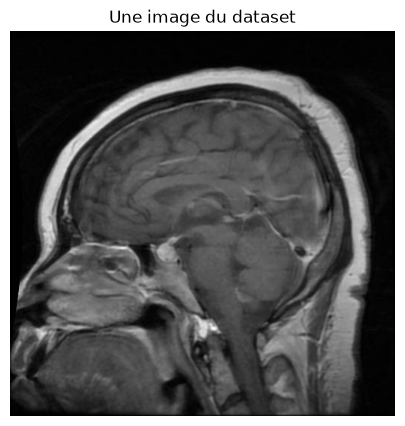

In [45]:
plt.figure(figsize=(5, 5))
plt.imshow(pixels)
plt.title("Une image du dataset")
plt.axis("off")
plt.show()

Affichage de quelques exemples de chaque dossier.

`random.seed(42)` permet de retrouver la même sélection lors d'une réexécution.

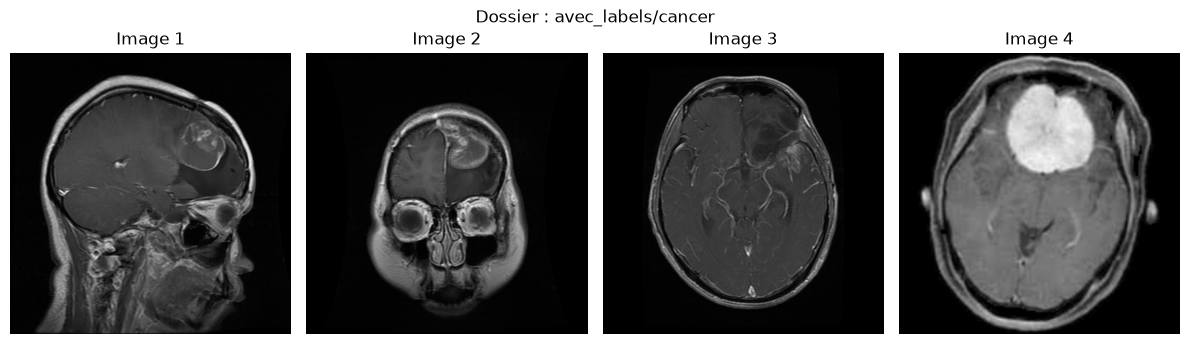

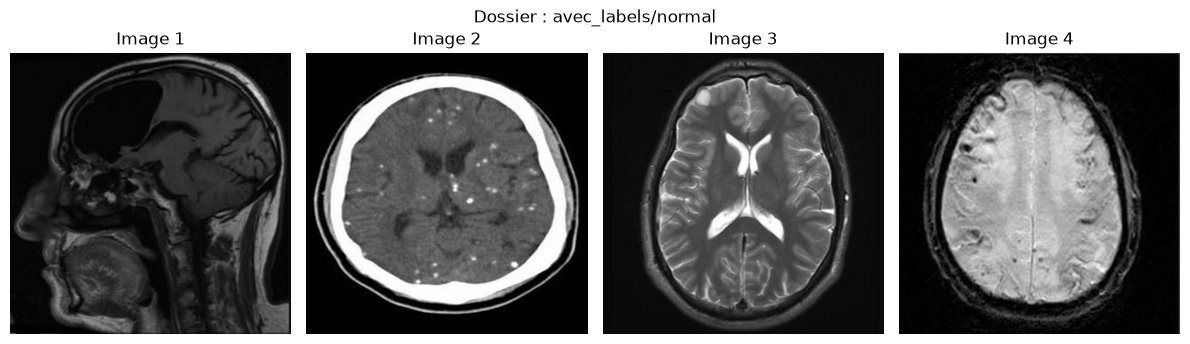

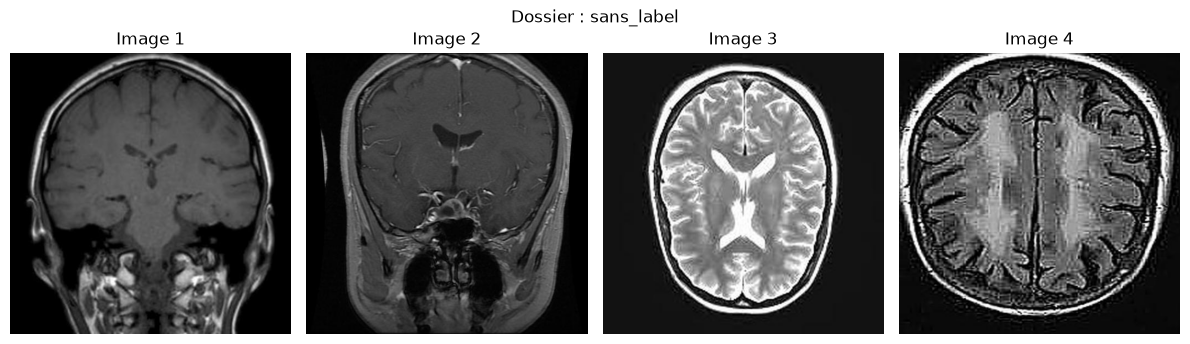

In [46]:
random.seed(42)

for dossier in dossiers:
    fichiers = sorted((dossier_dataset / dossier).glob("*.jpg"))
    exemples = random.sample(fichiers, min(4, len(fichiers)))

    plt.figure(figsize=(12, 3.5))
    for numero, chemin in enumerate(exemples, start=1):
        with Image.open(chemin) as image:
            pixels_exemple = np.array(image)

        plt.subplot(1, 4, numero)
        plt.imshow(pixels_exemple)
        plt.title(f"Image {numero}")
        plt.axis("off")

    plt.suptitle(f"Dossier : {dossier}")
    plt.tight_layout()
    plt.show()

Sélection d'un échantillon de 100 images.

Affichage du nombre d'images sélectionnées.

In [47]:
random.seed(42)
echantillon = random.sample(chemins_images, min(100, len(chemins_images)))

print("Nombre d'images à vérifier :", len(echantillon))

Nombre d'images à vérifier : 100


Pour chaque fichier de l'échantillon, appel de `image.load()` pour lire ses pixels. Ses dimensions, son mode de couleur, son nombre de canaux et son format. Les erreurs de lecture sont conservées et baffichées.

Affichage des premières lignes du tableau `controle`.

In [48]:
caracteristiques = []
erreurs = []

for chemin in echantillon:
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels/normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


Regroupons les images pour vérifier qu'elles ont les mêmes caractéristiques.

Regroupement des images par dimensions, mode de couleur, nombre de canaux et format, puis du nombre d'images lisibles et d'erreurs de lecture.

In [49]:
for chemin in sorted(dossier_dataset.rglob("*.jpg")):
    try:
        with Image.open(chemin) as image:
            image.load()
            caracteristiques.append({
                "Fichier": chemin.name,
                "Dossier": str(chemin.parent.relative_to(dossier_dataset)),
                "Largeur": image.width,
                "Hauteur": image.height,
                "Mode": image.mode,
                "Canaux": len(image.getbands()),
                "Format": image.format,
            })
    except OSError as erreur:
        erreurs.append({"Fichier": str(chemin), "Erreur": str(erreur)})

controle = pd.DataFrame(caracteristiques)
display(controle.head())

resume = controle.groupby(["Largeur", "Hauteur", "Mode", "Canaux"]).size()
display(resume.to_frame("Nombre d'images"))
display(controle["Format"].value_counts().to_frame("Nombre d'images"))

print("Images lisibles dans le dataset :", len(controle))
print("Erreurs de lecture :", len(erreurs))

if erreurs:
    display(pd.DataFrame(erreurs))

,Fichier,Dossier,Largeur,Hauteur,Mode,Canaux,Format
0,de4a58ef-0572-499a-8b39-437d6605102e.jpg,sans_label,512,512,RGB,3,JPEG
1,1567a15d-5f22-46ca-a77c-cd88ee60b7fd.jpg,sans_label,512,512,RGB,3,JPEG
2,09316c60-86c8-4f24-934e-8d433b8b9d72.jpg,avec_labels/normal,512,512,RGB,3,JPEG
3,5674a7bf-6fe6-4c43-b574-fdd81608e18b.jpg,sans_label,512,512,RGB,3,JPEG
4,4a4822ad-22e0-4dac-a072-18fe2824cc9f.jpg,sans_label,512,512,RGB,3,JPEG


,,,,Nombre d'images
Largeur,Hauteur,Mode,Canaux,
512,512,RGB,3,1606


,Nombre d'images
Format,
JPEG,1606


Images lisibles dans le dataset : 1606
Erreurs de lecture : 0


Recherche de doublons et affichage de l'unb d'entre eux

In [50]:


images_vues = {}
doublons = []

for chemin in chemins_images:
    with Image.open(chemin) as image:
        image_rgb = image.convert("RGB")
        empreinte = hashlib.sha256(image_rgb.tobytes()).hexdigest()
        signature = (image_rgb.size, empreinte)

    if signature in images_vues:
        doublons.append((images_vues[signature], chemin))
    else:
        images_vues[signature] = chemin

print("Nombre d'images examinées :", len(chemins_images))
print("Nombre de doublons :", len(doublons))

display(pd.DataFrame(doublons, columns=["Première image", "Copie"]))

Nombre d'images examinées : 1506
Nombre de doublons : 96


,Première image,Copie
0,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/avec_labels/normal...
1,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/04dd2b7...
2,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/16a1699...
3,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/18599c4...
4,mri_dataset_brain_cancer_oc/avec_labels/normal...,mri_dataset_brain_cancer_oc/sans_label/194106c...
...,...,...
91,mri_dataset_brain_cancer_oc/sans_label/1212636...,mri_dataset_brain_cancer_oc/sans_label/f84cb0d...
92,mri_dataset_brain_cancer_oc/avec_labels/cancer...,mri_dataset_brain_cancer_oc/sans_label/f946618...
93,mri_dataset_brain_cancer_oc/sans_label/abac225...,mri_dataset_brain_cancer_oc/sans_label/fa8ec37...
94,mri_dataset_brain_cancer_oc/sans_label/f9d60d2...,mri_dataset_brain_cancer_oc/sans_label/fcf1c2e...


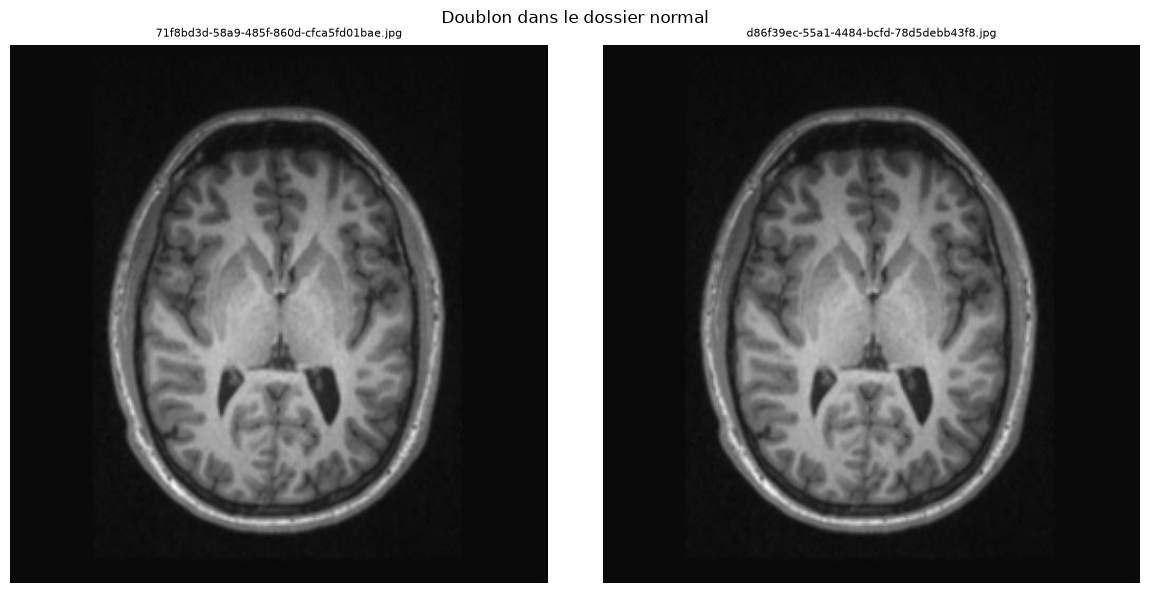

In [51]:
dossier_normal = Path("mri_dataset_brain_cancer_oc/avec_labels/normal")

fichiers = [
    "71f8bd3d-58a9-485f-860d-cfca5fd01bae.jpg",
    "d86f39ec-55a1-4484-bcfd-78d5debb43f8.jpg",
]

plt.figure(figsize=(12, 6))

for numero, nom in enumerate(fichiers, start=1):
    with Image.open(dossier_normal / nom) as image:
        plt.subplot(1, 2, numero)
        plt.imshow(image)

    plt.title(nom, fontsize=8)
    plt.axis("off")

plt.suptitle("Doublon dans le dossier normal")
plt.tight_layout()
plt.show()

Conclusion

- Le comptage donne **1 506 images JPEG** : 50 dans cancer, 50 dans normal et 1 406 dans sans_label.
- Les deux classes étiquetées sont équilibrées.
- Le dossier sans label contient **six images de plus** que le descriptif.
- Les images mesurent **512 × 512 pixels** et sont stockées en **RGB, avec trois canaux**.
- Aucune erreur de lecture n'a été rencontrée dans cet échantillon.
- Les images montrent différentes orientations de coupe et différents cadrages.
- La place occupée par le cerveau, le contraste et la netteté apparente varient.
- Les exemples apparaissent principalement en niveaux de gris malgré le stockage RGB.
- Une même taille de 512 × 512 pixels ne garantit pas une qualité visuelle uniforme.
- Le dataset contient 96 copies supplémentaires.

Ces doublons seront à traiter.

Traitement des doublons.

On écarte les doublons de la liste `chemins_images`, en conservant la première occurrence de chaque image. Les fichiers sources restent inchangés.

Affichage du nombre d'images avant filtrage, des copies écartées et des images conservées pour l'étape 2.

In [52]:
nombre_images_avant = len(chemins_images)

# Récupérer les chemins des copies supplémentaires.
copies_a_ecarter = {
    copie for premiere_image, copie in doublons
}

# Conserver uniquement la première occurrence de chaque image.
chemins_images = [
    chemin for chemin in chemins_images
    if chemin not in copies_a_ecarter
]

print("Images avant filtrage :", nombre_images_avant)
print("Copies écartées :", nombre_images_avant - len(chemins_images))
print("Images conservées pour l'étape 2 :", len(chemins_images))

Images avant filtrage : 1506
Copies écartées : 96
Images conservées pour l'étape 2 : 1410


## Étape 2 : prétraitement et extraction des features

### Mesurer la durée et la RAM pour evaluer la puissance nécéssaire pour ce projet

Définition de `mesurer_ressources`, qui mesurera la durée et suivra la RAM du processus Python toutes les 0,05 seconde avec `psutil`.
Chaque mesure conservera la RAM au départ, le maximum observé et l'augmentation maximale, en Mio. Les pauses entre cellules ne sont pas comptées dans ces mesures.

La cellule affiche que la mesure est prête.

In [53]:


mesures_ressources = {}
processus_python = psutil.Process()

@contextmanager
def mesurer_ressources(nom, groupe="Création du modèle"):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    ram_depart = processus_python.memory_info().rss
    pic_ram = [ram_depart]
    arret = Event()

    def suivre_ram():
        while not arret.wait(0.05):
            pic_ram[0] = max(pic_ram[0], processus_python.memory_info().rss)

    suivi = Thread(target=suivre_ram, daemon=True)
    suivi.start()
    debut = time.perf_counter()
    try:
        yield
    finally:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        duree = time.perf_counter() - debut
        arret.set()
        suivi.join()
        pic_ram[0] = max(pic_ram[0], processus_python.memory_info().rss)
        mesures_ressources[nom] = {
            "Groupe": groupe,
            "Opération": nom,
            "Durée (s)": duree,
            "RAM au départ (Mio)": ram_depart / 1024**2,
            "Pic RAM (Mio)": pic_ram[0] / 1024**2,
            "Hausse maximale (Mio)": (pic_ram[0] - ram_depart) / 1024**2,
        }

print("Mesure de la durée et du pic de RAM prête.")

Mesure de la durée et du pic de RAM prête.


Choix des poids pré-entraînés de ResNet18 : `IMAGENET1K_V1`.

Configuration du prétraitement qui réalisera le redimensionnement, le recadrage, la conversion et la normalisation des images.

Affichage des paramètres de ce prétraitement.

In [54]:


poids = models.ResNet18_Weights.IMAGENET1K_V1
pretraitement = poids.transforms()
print(pretraitement)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


définition de la fcontion de pretraitement:
- equalize(image) égalise les pixels : elle redistribue les valeurs de luminosité pour modifier le contraste de l’image.
- pretraitement_imagenet(image_egalisee) applique ensuite le prétraitement associé aux poids choisis : redimensionnement, recadrage, conversion en valeurs décimales et normalisation.- 

In [ ]:

# Egaliser les pixels uint8 avant la normalisation ImageNet.
pretraitement_imagenet = poids.transforms()

def pretraitement(image):
    image_egalisee = equalize(image)
    return pretraitement_imagenet(image_egalisee)

print("Egalisation des histogrammes avant le prétraitement ImageNet.")
print(pretraitement_imagenet)

Egalisation des histogrammes avant le prétraitement ImageNet.
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Application de `pretraitement` à chaque image conservée dans `chemins_images`.
Stockage du résultat dans la liste `images_preparees`.

Affichage du nombre d'images préparées, de leur forme et du type de leurs valeurs.
La durée et le pic de RAM de cette cellule sont mesurés.

In [57]:
with mesurer_ressources('Préparation et égalisation des images'):
    images_preparees = []

    for chemin in chemins_images:
        image = read_image(str(chemin), mode=ImageReadMode.RGB)
        images_preparees.append(pretraitement(image))

    print("Nombre d'images préparées :", len(images_preparees))
    print("Forme d'une image préparée :", tuple(images_preparees[0].shape))
    print("Type des valeurs :", images_preparees[0].dtype)

Nombre d'images préparées : 1410
Forme d'une image préparée : (3, 224, 224)
Type des valeurs : torch.float32


Chargement de ResNet18 avec les poids pré-entraînés précédemment choisis.
Gel des paramètres avec `requires_grad = False`, y compris ceux des couches convolutionnelles.

On remplace la couche de classification par `torch.nn.Identity()` pour que le modèle renvoie les 512 nombres décrivant chaque image. `modele.eval()` le place en mode évaluation.

Puis on vérifie que les paramètres sont bien gelés en affichant le nombre de paramètres entraînables.

La durée et le pic de RAM de cette cellule sont mesurés.

In [58]:
with mesurer_ressources('Chargement du modèle d’extraction'):
    modele = models.resnet18(weights=poids)

    for parametre in modele.parameters():
        parametre.requires_grad = False

    modele.fc = torch.nn.Identity()
    modele.eval()

    print("Nombre de paramètres entraînables :", sum(
        parametre.numel() for parametre in modele.parameters() if parametre.requires_grad
    ))

Nombre de paramètres entraînables : 0


Extraction des embeddings des images préparées :

- On traite les images préparées par lots de 16 : pour chaque image, le modèle crée un vecteur de 512 nombres décrivant l'image.
- On ajoute avec `append()` chaque lot de vecteurs dans `blocs_features`.
- Après la boucle, on concatène avec `np.concatenate()` les blocs en un tableau unique.

Affichage de la progression et des dimensions de `matrice_features`.
La durée et le pic de RAM de cette cellule sont mesurés.

In [59]:
with mesurer_ressources('Extraction des embeddings layer4'):
    taille_lot = 16
    blocs_features = []

    for debut in range(0, len(images_preparees), taille_lot):
        images_lot = images_preparees[debut:debut + taille_lot]
        lot = torch.stack(images_lot)
        features_lot = modele(lot).numpy()
        blocs_features.append(features_lot)

        nombre_traite = debut + len(images_lot)
        if debut % (taille_lot * 10) == 0 or nombre_traite == len(images_preparees):
            print(f"Images traitées : {nombre_traite} / {len(images_preparees)}")

    matrice_features = np.concatenate(blocs_features, axis=0)
    print("Forme de la matrice de features :", matrice_features.shape)

Images traitées : 16 / 1410


KeyboardInterrupt: 

### Essai d'une couche intermédiaire

- Réutiliser les couches gelées de `modele` jusqu'à `layer3`, en arrêtant avant `layer4`.
- Traiter `images_preparees` par lots de 16 et afficher les dimensions des deux matrices.
- Cet essai reste en mémoire et ne remplace pas `matrice_features`, qui contient les embeddings habituels de 512 dimensions. La durée et le pic de RAM de cet essai sont mesurés.

In [ ]:
with mesurer_ressources("Essai des embeddings layer3"):
    modele_intermediaire = torch.nn.Sequential(
        modele.conv1, modele.bn1, modele.relu, modele.maxpool,
        modele.layer1, modele.layer2, modele.layer3,
        torch.nn.AdaptiveAvgPool2d((1, 1)),
        torch.nn.Flatten(),
    )
    modele_intermediaire.eval()
    blocs_intermediaires = []

    with torch.no_grad():
        for debut in range(0, len(images_preparees), taille_lot):
            lot = torch.stack(images_preparees[debut:debut + taille_lot])
            blocs_intermediaires.append(modele_intermediaire(lot).numpy())

    matrice_features_intermediaires = np.concatenate(blocs_intermediaires, axis=0)

display(pd.DataFrame({
    "Embeddings": ["Habituels : layer4", "Intermédiaires : layer3"],
    "Nombre d'images": [len(matrice_features), len(matrice_features_intermediaires)],
    "Dimensions du vecteur": [matrice_features.shape[1], matrice_features_intermediaires.shape[1]],
}))

,Embeddings,Nombre d'images,Dimensions du vecteur
0,Habituels : layer4,1410,512
1,Intermédiaires : layer3,1410,256


Transformation de `matrice_features` en tableau pandas nommé `features`, avec les colonnes numériques nommées `feature_000` à `feature_511`.

La première colonne du tableau contient le chemin relatif de l'image.

Affichage des dimensions et des premières lignes du tableau.
La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Création du tableau de features'):
    colonnes_features = [f"feature_{numero:03d}" for numero in range(512)]
    features = pd.DataFrame(matrice_features, columns=colonnes_features)
    features.insert(0, "chemin", [
        chemin.relative_to(dossier_dataset).as_posix() for chemin in chemins_images
    ])

    print("Forme du tableau :", features.shape)
    display(features.head())

Forme du tableau : (1410, 513)


,chemin,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,avec_labels/cancer/05340cd4-3bb2-459d-9937-bf2...,0.427524,1.104707,1.259579,0.924095,0.844503,0.227289,3.558287,0.464598,0.409305,...,0.175422,0.722887,0.229013,0.463600,0.738762,0.799517,0.140114,0.495540,0.677190,1.773725
1,avec_labels/cancer/0c6f3641-60d9-4a76-abe5-de8...,1.007465,0.752441,1.473011,1.305458,0.512741,0.181812,1.341352,0.928920,0.764852,...,0.291133,0.027831,1.492801,0.915967,0.374627,2.466898,1.044379,1.002124,0.440500,0.020950
2,avec_labels/cancer/0f718241-8f63-4b55-81ce-315...,3.150179,1.437924,1.317395,1.865548,0.621477,0.056884,0.638822,0.701910,0.582480,...,0.060915,0.753785,0.997984,1.027417,0.838853,1.636198,1.717380,1.792489,0.689742,0.066517
3,avec_labels/cancer/11a7a426-4806-401e-98b2-b96...,3.644767,1.381258,1.123361,0.504585,1.479513,0.002588,1.434992,0.111483,1.806756,...,1.228689,1.111359,0.922810,2.786142,1.676367,1.425794,0.150988,1.483569,1.135730,0.489558
4,avec_labels/cancer/1c043dbb-4623-4769-8e5e-022...,1.861620,0.778502,2.320082,0.980373,0.683178,0.018706,2.488113,0.771759,0.541074,...,0.182427,0.187408,0.875488,1.312935,0.364541,0.921724,0.531714,2.628416,0.000000,2.191153


Sauvegarde dans un tableau .csv pour l'utiliser par la suite

In [ ]:
with mesurer_ressources('Sauvegarde du tableau CSV'):
    chemin_features = Path("resultats/etape2/features_resnet18.csv")
    chemin_features.parent.mkdir(parents=True, exist_ok=True)

    features.to_csv(chemin_features, index=False)

    print("Tableau de features sauvegardé :", chemin_features)
    print("Forme du tableau :", features.shape)

Tableau de features sauvegardé : resultats/etape2/features_resnet18.csv
Forme du tableau : (1410, 513)


## Étape 3 : modélisation non supervisée

Chargement du tableau CSV sauvegardé, puis séparation avant les transformations : train, validation et test forts ; train et test sans label.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Lecture du CSV et séparation des ensembles'):
    features = pd.read_csv(chemin_features)

    masque_fort = features["chemin"].str.startswith("avec_labels/")
    masque_sans_label = features["chemin"].str.startswith("sans_label/")

    donnees_fortes = features.loc[masque_fort].copy()
    donnees_fortes["label_fort"] = donnees_fortes["chemin"].str.split("/").str[1]
    donnees_sans_label = features.loc[masque_sans_label].copy()

    # Réserver le test fort, puis la validation forte.
    fortes_train, fortes_test = train_test_split(
        donnees_fortes,
        test_size=0.2,
        stratify=donnees_fortes["label_fort"],
        random_state=42,
    )
    fortes_train, fortes_validation = train_test_split(
        fortes_train,
        test_size=0.2,
        stratify=fortes_train["label_fort"],
        random_state=42,
    )

    # Les images sans label sont séparées avant leur labellisation faible.
    sans_label_train, sans_label_test = train_test_split(
        donnees_sans_label,
        test_size=0.2,
        random_state=42,
    )

    print("Train fort :", len(fortes_train))
    print("Validation forte :", len(fortes_validation))
    print("Test fort :", len(fortes_test))
    print("Train sans label :", len(sans_label_train))
    print("Test sans label :", len(sans_label_test))

Train fort : 63
Validation forte : 16
Test fort : 20
Train sans label : 1048
Test sans label : 263


Standardisation des features de sans_label_train avec StandardScaler. Les paramètres sont appris uniquement sur cet ensemble. Affichage des dimensions et des premières lignes du tableau standardisé.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Standardisation des embeddings'):
    X_features = sans_label_train[colonnes_features]

    standardisation = StandardScaler()
    X_standardise = standardisation.fit_transform(X_features)

    print("Forme des features du train sans label standardisées :", X_standardise.shape)
    display(pd.DataFrame(X_standardise, columns=colonnes_features).head())

Forme des features du train sans label standardisées : (1048, 512)


,feature_000,feature_001,feature_002,feature_003,feature_004,feature_005,feature_006,feature_007,feature_008,feature_009,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,0.995024,1.284425,1.921115,-0.483798,-0.552284,-0.640420,-0.031213,-0.647501,2.607586,0.266281,...,-1.205876,0.032547,0.298444,0.699895,0.745454,0.022585,0.293591,-0.691926,0.940945,-0.513007
1,-1.050577,-1.162886,-1.810363,1.724878,0.336955,-0.659383,-1.028642,3.602089,-1.089429,0.855240,...,0.703067,-0.889925,2.022208,-1.327907,-0.593034,1.524950,4.755812,-0.452853,-1.088293,1.273830
2,0.859232,1.743542,0.736570,-0.358303,0.081546,-0.642732,-0.151610,-0.558386,1.581521,0.858876,...,-1.070134,2.952065,0.090871,0.337176,0.846594,-0.352458,0.797274,-0.002188,0.257810,-1.161233
3,-0.389651,1.792935,0.901781,-0.880695,-0.337089,-0.626834,0.627817,0.562413,0.003361,-0.973738,...,-0.801484,-0.770781,1.122118,0.466277,2.215956,0.845379,-0.089319,-0.885148,-0.609771,-1.050168
4,0.760513,1.755103,1.518946,0.714504,1.696320,-0.552690,1.114578,-0.895017,-0.319853,1.163692,...,-1.120286,-0.479783,3.610925,-1.262984,0.089626,0.877109,-0.937630,-0.698250,-0.347843,-0.816078


Réduction à deux dimensions : la PCA est apprise uniquement sur le train sans label. Les ensembles forts et le test sans label sont transformés avec la standardisation et la PCA déjà apprises. Affichage des dimensions de chaque ensemble.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('PCA des embeddings'):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_standardise)

    # Transformer séparément les données fortes, sans réapprentissage.
    X_fort_pca = pca.transform(standardisation.transform(
        fortes_train[colonnes_features]
    ))
    X_validation_pca = pca.transform(standardisation.transform(
        fortes_validation[colonnes_features]
    ))
    X_fort_test_pca = pca.transform(standardisation.transform(
        fortes_test[colonnes_features]
    ))

    # Transformer le test sans label avec les mêmes paramètres.
    X_test_pca = pca.transform(standardisation.transform(
        sans_label_test[colonnes_features]
    ))

    print("PCA train fort :", X_fort_pca.shape)
    print("PCA train sans label :", X_pca.shape)
    print("PCA validation forte :", X_validation_pca.shape)
    print("PCA test fort :", X_fort_test_pca.shape)
    print("PCA test sans label :", X_test_pca.shape)

PCA train fort : (63, 2)
PCA train sans label : (1048, 2)
PCA validation forte : (16, 2)
PCA test fort : (20, 2)
PCA test sans label : (263, 2)


Réalisation du clustering avec K-Means.

- `n_clusters=2` pour la séparation en deux groupes, comme pour le dataset labellisé.
- `random_state=42` pour pouvoir reproduire le clustering.

K-Means est entraîné uniquement sur le train sans label. Affichage des effectifs de chaque groupe.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Clustering K-Means'):
    # X_pca contient uniquement le train sans label.
    kmeans = KMeans(n_clusters=2, random_state=42)
    groupes_kmeans_sans_label = kmeans.fit_predict(X_pca)

    display(pd.Series(groupes_kmeans_sans_label).value_counts().sort_index().to_frame("Nombre d'images"))

,Nombre d'images
0,565
1,483


Graphique illustrant les coordonnées des images du train sans label.

Chaque point représente une image, placée selon ses deux coordonnées PCA. Sa couleur indique le groupe attribué par K-Means.

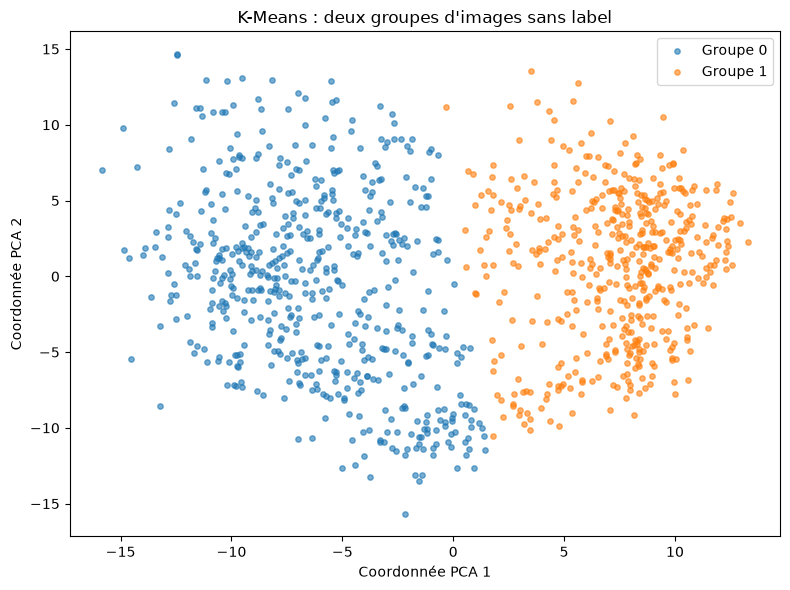

In [ ]:
plt.figure(figsize=(8, 6))

for groupe in [0, 1]:
    selection = groupes_kmeans_sans_label == groupe
    plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                s=15, alpha=0.6, label=f"Groupe {groupe}")

plt.xlabel("Coordonnée PCA 1")
plt.ylabel("Coordonnée PCA 2")
plt.title("K-Means : deux groupes d'images sans label")
plt.legend()
plt.tight_layout()
plt.show()

K-Means répartit les images en deux groupes, principalement séparés par l'abscisse PCA (gauche et droite). Les groupes présentent une dispersion interne. Cette représentation montre des différences entre les images, sans pour autant identifier les groupes comme « normal » et « cancer ».

Réalisation du clustering avec DBSCAN.

Choix de neuf combinaisons à tester pour visualiser ensuite les résultats. On teste toutes les combinaisons entre :

- `eps` (rayon du voisinage) : 0.5, 1.0, 2.0 ;
- `min_samples` (nombre minimum de points dans ce voisinage, en comptant le point lui-même) : 3, 5, 10.

Chaque résultat est conservé dans `essais_dbscan` avec ses paramètres, ses numéros de groupes, le nombre de groupes et le nombre d'images hors groupe (`-1`).

DBSCAN est entraîné uniquement sur le train sans label. Affichage des paramètres et des effectifs pour chaque essai.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Essais DBSCAN'):
    # Les neuf essais utilisent uniquement le train sans label.
    essais_dbscan = []

    for eps in [0.5, 1.0, 2.0]:
        for min_samples in [3, 5, 10]:
            dbscan_essai = DBSCAN(eps=eps, min_samples=min_samples)
            groupes_essai = dbscan_essai.fit_predict(X_pca)
            nombre_groupes_essai = len(set(groupes_essai) - {-1})
            nombre_hors_groupe_essai = int((groupes_essai == -1).sum())

            essais_dbscan.append({
                "eps": eps,
                "min_samples": min_samples,
                "groupes": groupes_essai,
                "nombre_groupes": nombre_groupes_essai,
                "nombre_hors_groupe": nombre_hors_groupe_essai,
            })

            print(f"eps={eps}, min_samples={min_samples} : "
                  f"{nombre_groupes_essai} groupe(s), "
                  f"{nombre_hors_groupe_essai} image(s) hors groupe")

eps=0.5, min_samples=3 : 93 groupe(s), 368 image(s) hors groupe
eps=0.5, min_samples=5 : 36 groupe(s), 706 image(s) hors groupe
eps=0.5, min_samples=10 : 2 groupe(s), 1028 image(s) hors groupe
eps=1.0, min_samples=3 : 15 groupe(s), 51 image(s) hors groupe
eps=1.0, min_samples=5 : 8 groupe(s), 112 image(s) hors groupe
eps=1.0, min_samples=10 : 12 groupe(s), 373 image(s) hors groupe
eps=2.0, min_samples=3 : 1 groupe(s), 8 image(s) hors groupe
eps=2.0, min_samples=5 : 1 groupe(s), 10 image(s) hors groupe
eps=2.0, min_samples=10 : 1 groupe(s), 18 image(s) hors groupe


Affichage d'un graphique pour chaque essai de paramètres avec DBSCAN : une couleur représente chaque groupe ; les points hors groupe (`-1`) sont affichés en gris.

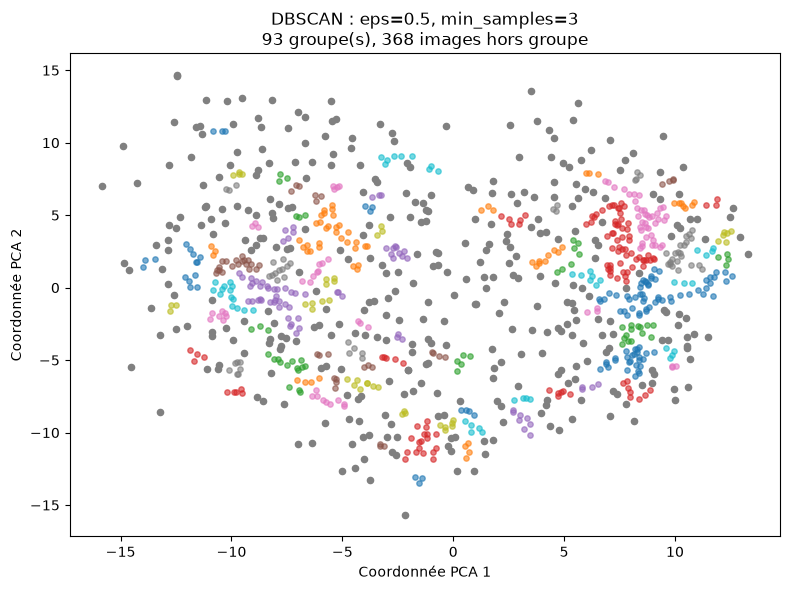

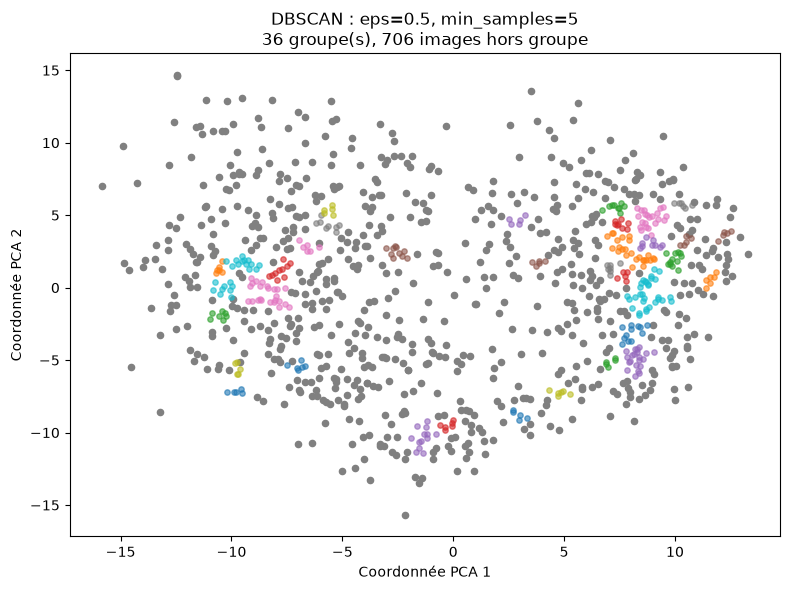

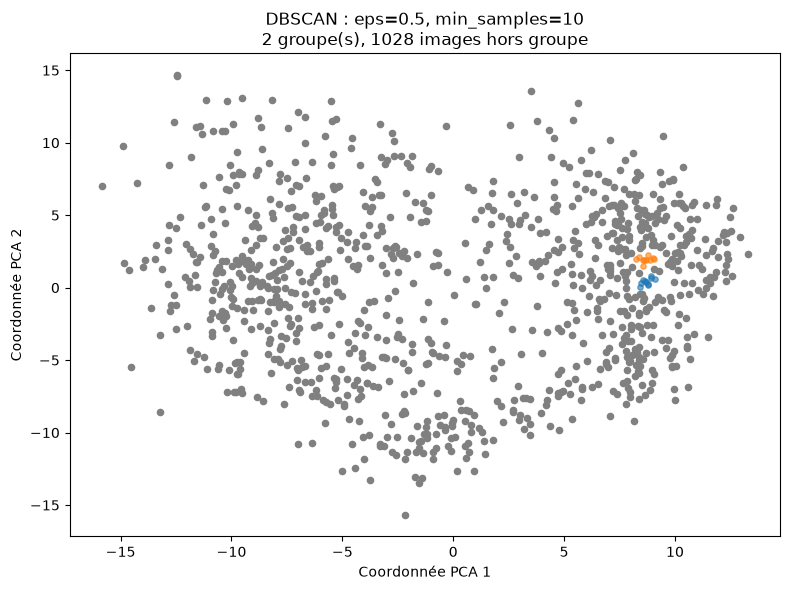

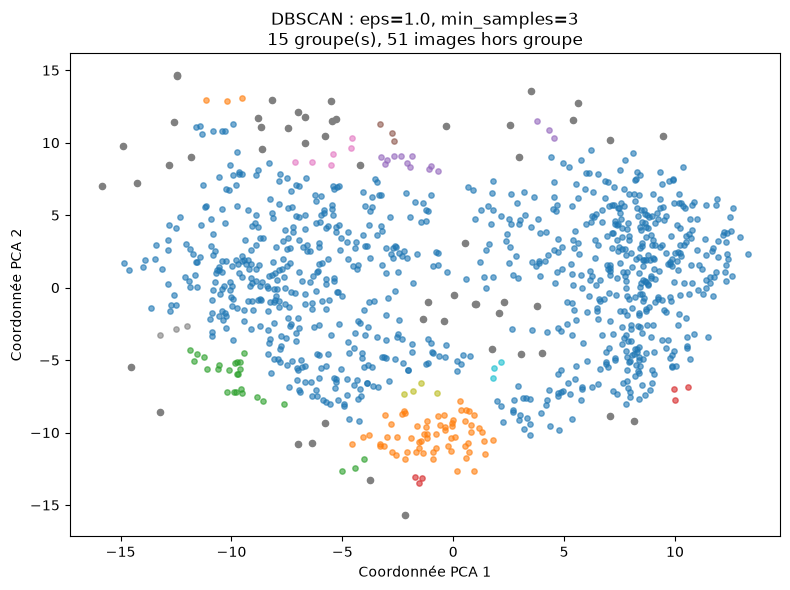

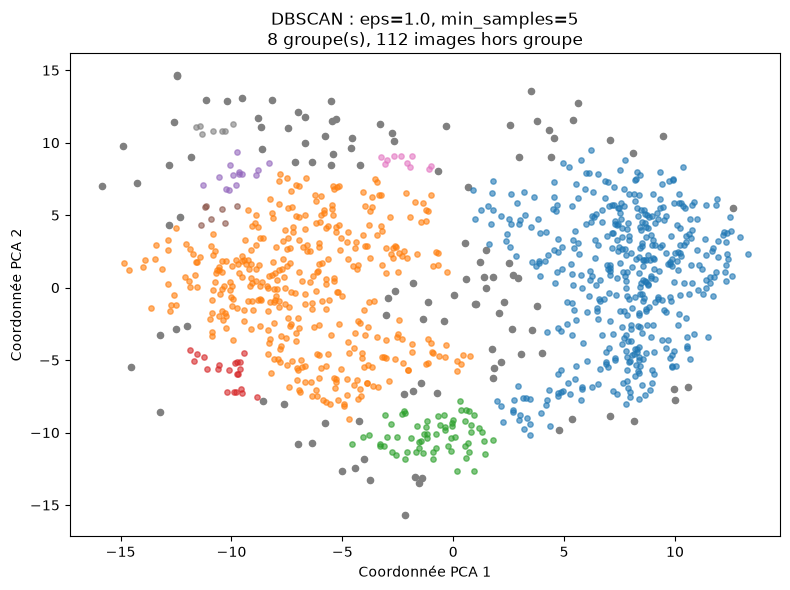

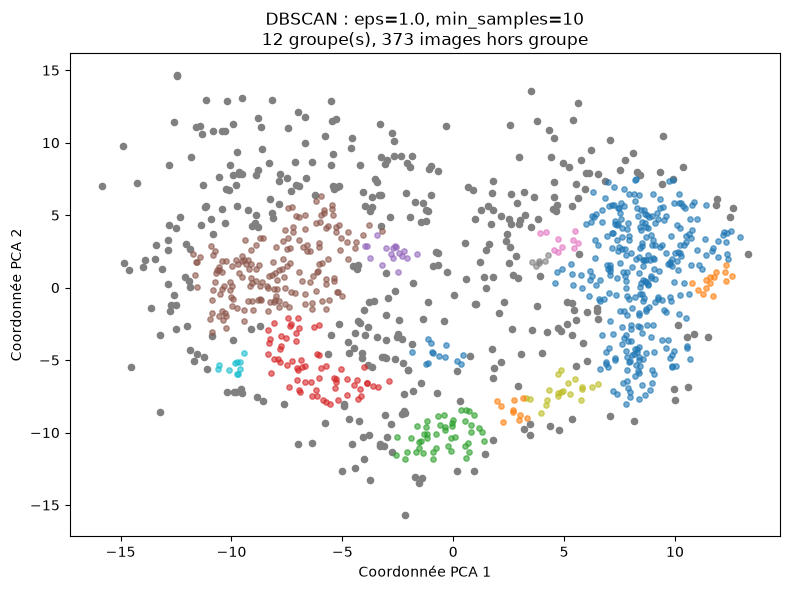

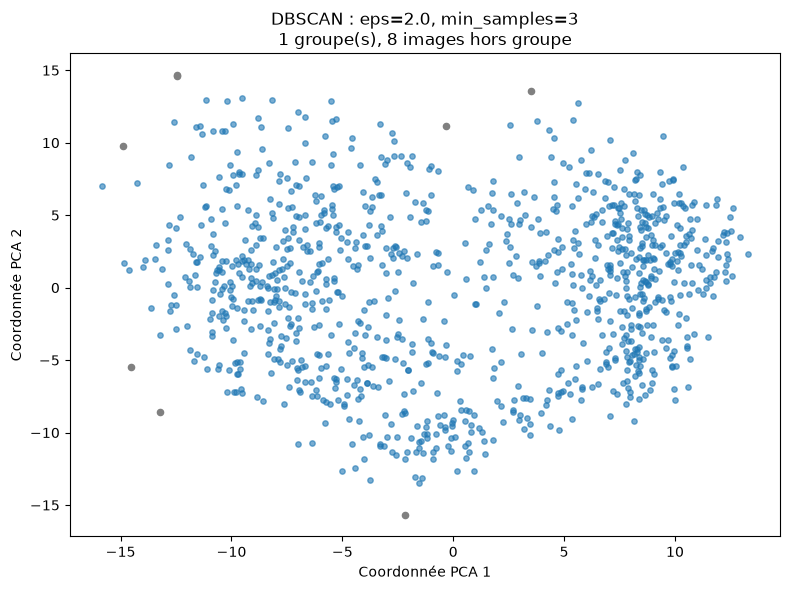

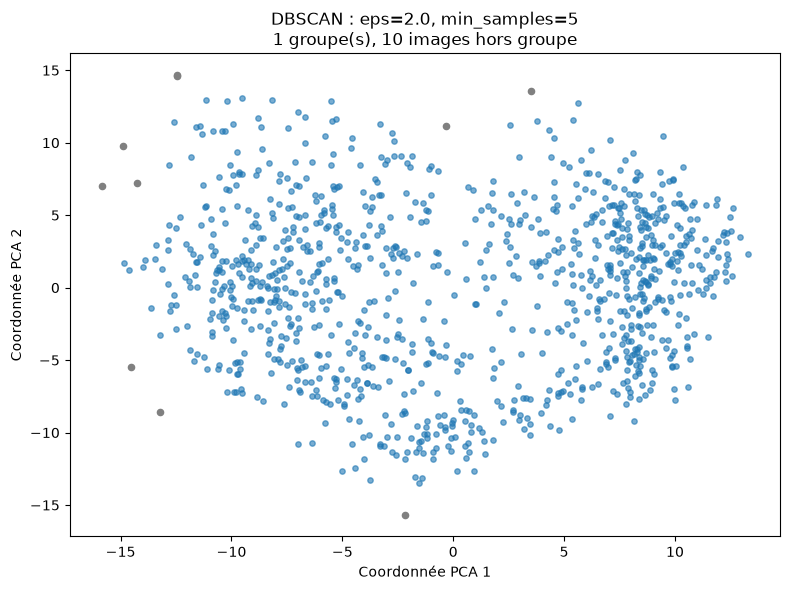

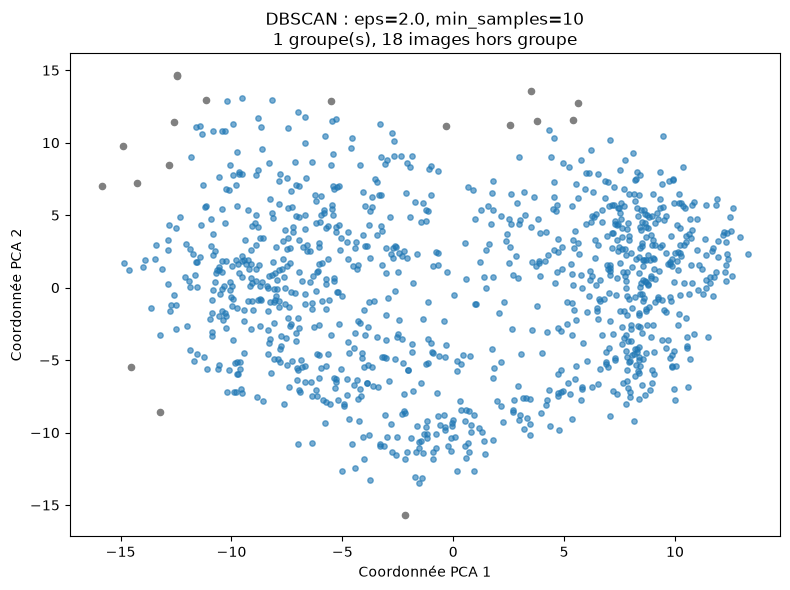

In [ ]:
for essai in essais_dbscan:
    groupes_essai = essai["groupes"]
    plt.figure(figsize=(8, 6))

    for groupe in sorted(set(groupes_essai)):
        selection = groupes_essai == groupe
        if groupe == -1:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=20, color="gray", label="Hors groupe (-1)")
        else:
            plt.scatter(X_pca[selection, 0], X_pca[selection, 1],
                        s=15, alpha=0.6, label=f"Groupe {groupe}")

    plt.xlabel("Coordonnée PCA 1")
    plt.ylabel("Coordonnée PCA 2")
    plt.title(
        f"DBSCAN : eps={essai['eps']}, min_samples={essai['min_samples']}\n"
        f"{essai['nombre_groupes']} groupe(s), "
        f"{essai['nombre_hors_groupe']} images hors groupe"
    )
    plt.tight_layout()
    plt.show()

Avec `eps=0.5` et `min_samples=10`, DBSCAN peut produir deux groupes, mais laisse 1 028 des 1 048 images hors groupe. Les autres essais produisent un nombre de groupes différent de deux. Je conserve donc K-Means pour la labellisation faible : il répartit toutes les images en deux groupes.


### 3.9. Calcul du score ARI de K-Means

Réunir les 63 images fortes d'entraînement et les 16 de validation pour évaluer les groupes K-Means sur 79 images. Leurs coordonnées PCA sont déjà calculées. Les 20 images fortes de test sont exclues.

Résultat : un tableau avec le nombre d'images évaluées et le score ARI.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('ARI des embeddings layer4'):
    # Réunir uniquement les données fortes d'entraînement et de validation.
    donnees_ari = pd.concat([fortes_train, fortes_validation])
    X_ari = np.concatenate([X_fort_pca, X_validation_pca], axis=0)

    labels_reference = donnees_ari["label_fort"].to_numpy()
    groupes_kmeans_forts = kmeans.predict(X_ari)
    ari_kmeans = adjusted_rand_score(labels_reference, groupes_kmeans_forts)

    scores_ari = pd.DataFrame({
        "Méthode": ["K-Means"],
        "Nombre d'images fortes": [len(donnees_ari)],
        "ARI train + validation": [ari_kmeans],
    })
    display(scores_ari)

,Méthode,Nombre d'images fortes,ARI train + validation
0,K-Means,79,0.377289


L’ARI de 0,377 montre une correspondance partielle avec les labels connus. 

Les regroupements sont informatifs, mais la labellisation faible reste approximative.

### Comparer les embeddings habituels et intermédiaires

Tester `matrice_features_intermediaires` avec la même méthode : standardisation, PCA à deux dimensions et K-Means à deux groupes appris uniquement sur `sans_label_train`.
Calculer l'ARI sur les mêmes 79 images fortes d'entraînement et de validation (`donnees_ari`), puis afficher les deux scores. Les 20 images fortes de test restent réservées aux CNN.
Cet essai mesure sa durée et son pic de RAM ; il ne remplace pas les groupes K-Means déjà calculés pour la suite.

In [ ]:
with mesurer_ressources("Comparaison ARI des embeddings layer3"):
    standardisation_intermediaire = StandardScaler()
    X_intermediaire_standardise = standardisation_intermediaire.fit_transform(
        matrice_features_intermediaires[sans_label_train.index]
    )
    pca_intermediaire = PCA(n_components=2, random_state=42)
    X_intermediaire_pca = pca_intermediaire.fit_transform(X_intermediaire_standardise)
    kmeans_intermediaire = KMeans(n_clusters=2, random_state=42)
    kmeans_intermediaire.fit(X_intermediaire_pca)

    X_ari_intermediaire = pca_intermediaire.transform(
        standardisation_intermediaire.transform(
            matrice_features_intermediaires[donnees_ari.index]
        )
    )
    ari_intermediaire = adjusted_rand_score(
        labels_reference, kmeans_intermediaire.predict(X_ari_intermediaire)
    )

comparaison_embeddings = pd.DataFrame({
    "Embeddings": ["Habituels : layer4", "Intermédiaires : layer3"],
    "Dimensions": [512, 256],
    "ARI train + validation": [ari_kmeans, ari_intermediaire],
})
display(comparaison_embeddings.round(4))

,Embeddings,Dimensions,ARI train + validation
0,Habituels : layer4,512,0.3773
1,Intermédiaires : layer3,256,0.0339


Labels faibles du train sans label issus de K-Means ; labels du test sans label prédits sans réentraînement. Les labels forts restent séparés.

Affichage des effectifs et des premières lignes du tableau des labels faibles.
La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Attribution des labels faibles'):
    faibles_train = sans_label_train.copy()
    faibles_train["label_faible"] = groupes_kmeans_sans_label

    faibles_test = sans_label_test.copy()
    faibles_test["label_faible"] = kmeans.predict(X_test_pca)

    # Conserver le tableau des labels faibles, sans le mélanger aux labels forts.
    donnees_faibles = pd.concat([faibles_train, faibles_test]).sort_index()

    print("Méthode utilisée pour les labels faibles : K-Means")
    print("Images fortement labellisées, conservées séparément :", len(donnees_fortes))
    print("Images faiblement labellisées :", len(donnees_faibles))
    print("Train faible :", len(faibles_train))
    print("Test faible :", len(faibles_test))
    display(donnees_faibles[["chemin", "label_faible"]].head())
    display(donnees_faibles["label_faible"].value_counts().sort_index().to_frame("Nombre d'images"))

Méthode utilisée pour les labels faibles : K-Means
Images fortement labellisées, conservées séparément : 99
Images faiblement labellisées : 1311
Train faible : 1048
Test faible : 263


,chemin,label_faible
99,sans_label/001b158a-7af8-451e-bf31-3a9116265f3...,0
100,sans_label/00366e8d-5520-4d3c-a70b-91a7eec1f52...,1
101,sans_label/00455a62-f79f-4072-9a23-4951e759acd...,1
102,sans_label/004ce5f5-ca6b-490f-9b2f-c322c152e2e...,1
103,sans_label/005d9a37-8894-4eb5-8367-1015d4a4363...,0


,Nombre d'images
label_faible,
0,728
1,583


## Étape 4 : entraînement du CNN

Métriques utilisées :

- L'accuracy mesure la proportion globale de bonnes prédictions.
- La précision indique la fiabilité des prédictions « cancer ».
- Le rappel mesure la proportion d'images cancéreuses reconnues.
- Le F1 résume l'équilibre entre précision et rappel.
- Dans cette étude exploratoire, je privilégie le F2 pour sélectionner les hyperparamètres, pour privilégier la détection des images cancéreuses et pénaliser davantage les cancers classés à tort comme normaux.
- La matrice de confusion permet de voir directement les erreurs.

Réutilisation des ensembles train, validation et test réservés à l’étape 3. Affichage des effectifs par label.

In [ ]:
# Réutiliser les ensembles réservés à l’étape 3.
effectifs_faibles = pd.DataFrame({
    "Entraînement faible": faibles_train["label_faible"].value_counts(),
    "Test faible": faibles_test["label_faible"].value_counts(),
}).reindex([0, 1]).fillna(0).astype(int)

effectifs_forts = pd.DataFrame({
    "Entraînement fort": fortes_train["label_fort"].value_counts(),
    "Validation forte": fortes_validation["label_fort"].value_counts(),
    "Test fort": fortes_test["label_fort"].value_counts(),
}).reindex(["normal", "cancer"]).fillna(0).astype(int)

display(effectifs_faibles)
display(effectifs_forts)


,Entraînement faible,Test faible
label_faible,,
0,565,163
1,483,100


,Entraînement fort,Validation forte,Test fort
label_fort,,,
normal,31,8,10
cancer,32,8,10


Mise en forme des données pour le CNN :

- On associe chaque image à son étiquette. Les labels faibles conservent les numéros des groupes K-Means ; les labels forts sont encodés avec normal = 0 et cancer = 1.
- On prépare les chargeurs qui fourniront les couples image/étiquette au CNN.

Affichage du nombre de lots de chaque ensemble et de l'appareil utilisé.
La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Préparation des chargeurs CNN'):
    faibles_train["cible"] = faibles_train["label_faible"].astype(int)
    faibles_test["cible"] = faibles_test["label_faible"].astype(int)
    fortes_train["cible"] = fortes_train["label_fort"].map({"normal": 0, "cancer": 1})
    fortes_test["cible"] = fortes_test["label_fort"].map({"normal": 0, "cancer": 1})
    fortes_validation["cible"] = fortes_validation["label_fort"].map({"normal": 0, "cancer": 1})

    taille_lot_etape4 = 16
    epoques_faibles = 5
    epoques_fortes = 5
    taux_apprentissage = 0.001
    appareil_etape4 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    positions_images = {
        chemin.relative_to(dossier_dataset).as_posix(): position
        for position, chemin in enumerate(chemins_images)
    }

    def creer_chargeur(tableau, melanger):
        images = torch.stack([
            images_preparees[positions_images[chemin]]
            for chemin in tableau["chemin"]
        ])
        cibles = torch.tensor(tableau["cible"].to_numpy(), dtype=torch.long)
        dataset = TensorDataset(images, cibles)
        return DataLoader(
            dataset,
            batch_size=taille_lot_etape4,
            shuffle=melanger,
            generator=torch.Generator().manual_seed(42),
        )

    chargeur_faible = creer_chargeur(faibles_train, melanger=True)
    chargeur_test_faible = creer_chargeur(faibles_test, melanger=False)
    chargeur_fort = creer_chargeur(fortes_train, melanger=True)
    chargeur_validation = creer_chargeur(fortes_validation, melanger=False)
    chargeur_test = creer_chargeur(fortes_test, melanger=False)

    print("Lots d'entraînement faible :", len(chargeur_faible))
    print("Lots de test faible :", len(chargeur_test_faible))
    print("Lots d'entraînement fort :", len(chargeur_fort))
    print("Lots de validation forte :", len(chargeur_validation))
    print("Lots de test fort :", len(chargeur_test))
    print("Appareil utilisé :", appareil_etape4)

Lots d'entraînement faible : 66
Lots de test faible : 17
Lots d'entraînement fort : 4
Lots de validation forte : 1
Lots de test fort : 2
Appareil utilisé : cpu


Création de deux CNN :

- un pour l'entraînement semi-supervisé ;
- un pour l'entraînement supervisé.

On utilise les mêmes poids pré-entraînés qu'à l'étape 2. Les paramètres pré-entraînés sont gelés et seule la nouvelle couche finale à deux sorties est entraînable.

Affichage du nombre de paramètres entraînables de chaque CNN.
La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Création des deux CNN'):
    def creer_cnn():
        torch.manual_seed(42)
        cnn = models.resnet18(weights=poids)
        for parametre in cnn.parameters():
            parametre.requires_grad = False
        cnn.fc = torch.nn.Linear(cnn.fc.in_features, 2)
        return cnn.to(appareil_etape4)

    modele_semi = creer_cnn()
    modele_supervise = creer_cnn()
    fonction_perte = torch.nn.CrossEntropyLoss()

    optimiseur_semi = torch.optim.Adam(
        modele_semi.fc.parameters(), lr=taux_apprentissage
    )
    optimiseur_supervise = torch.optim.Adam(
        modele_supervise.fc.parameters(), lr=taux_apprentissage
    )

    for nom, cnn in [("Semi-supervisé", modele_semi), ("Supervisé", modele_supervise)]:
        print(nom, ": paramètres entraînables =", sum(
            parametre.numel() for parametre in cnn.parameters()
            if parametre.requires_grad
        ))

Semi-supervisé : paramètres entraînables = 1026
Supervisé : paramètres entraînables = 1026


Création de deux fonctions :

- `entrainer_cnn` entraîne le CNN en ajustant les poids de la couche finale et affiche la perte moyenne à chaque époque.
- `evaluer_cnn` réalise les prédictions sans modifier les poids, puis renvoie les métriques et la matrice de confusion. Les métriques sont l'accuracy, le F1, la précision, le rappel et le F2 pour le label 1 : groupe 1 sur les labels faibles, cancer sur les labels forts.

La cellule affiche que les fonctions sont définies.

In [ ]:
def entrainer_cnn(cnn, chargeur, optimiseur, nombre_epoques):
    chargeur.generator.manual_seed(42)
    pertes = []

    for epoque in range(nombre_epoques):
        cnn.eval()
        cnn.fc.train()
        perte_totale = 0.0

        for images_lot, cibles_lot in chargeur:
            images_lot = images_lot.to(appareil_etape4)
            cibles_lot = cibles_lot.to(appareil_etape4)

            optimiseur.zero_grad()
            sorties = cnn(images_lot)
            perte = fonction_perte(sorties, cibles_lot)
            perte.backward()
            optimiseur.step()
            perte_totale += perte.item() * len(cibles_lot)

        perte_moyenne = perte_totale / len(chargeur.dataset)
        pertes.append(perte_moyenne)
        print(f"Époque {epoque + 1}/{nombre_epoques} : perte = {perte_moyenne:.4f}")

    return pertes

def evaluer_cnn(cnn, chargeur):
    cnn.eval()
    matrice = np.zeros((2, 2), dtype=int)

    with torch.no_grad():
        for images_lot, cibles_lot in chargeur:
            sorties = cnn(images_lot.to(appareil_etape4))
            predictions = sorties.argmax(dim=1).cpu()
            for vraie_classe, classe_predite in zip(
                cibles_lot.tolist(), predictions.tolist()
            ):
                matrice[vraie_classe, classe_predite] += 1

    vrais_negatifs, faux_positifs, faux_negatifs, vrais_positifs = matrice.ravel()
    denominateur_f1 = 2 * vrais_positifs + faux_positifs + faux_negatifs
    denominateur_precision = vrais_positifs + faux_positifs
    denominateur_rappel = vrais_positifs + faux_negatifs
    denominateur_f2 = 5 * vrais_positifs + 4 * faux_negatifs + faux_positifs
    mesures = {
        "Accuracy": (vrais_negatifs + vrais_positifs) / matrice.sum(),
        "F1": 2 * vrais_positifs / denominateur_f1 if denominateur_f1 > 0 else 0.0,
        "Précision": vrais_positifs / denominateur_precision if denominateur_precision > 0 else 0.0,
        "Rappel": vrais_positifs / denominateur_rappel if denominateur_rappel > 0 else 0.0,
        "F2": 5 * vrais_positifs / denominateur_f2 if denominateur_f2 > 0 else 0.0,
    }
    return mesures, matrice

print("Fonctions d'entraînement et d'évaluation définies.")


Fonctions d'entraînement et d'évaluation définies.


Recherche d'hyperparamètres pour le modèle semi-supervisé :

- D'abord, comparaison de deux configurations sur les labels faibles : taux de 0,001 et 5 ou 10 époques. On utilise les 16 images de validation réservées à l'étape 3, avec leurs groupes K-Means comme cibles. On retient la meilleure accuracy d'accord avec ces groupes ; à score égal, on conserve 5 époques.
- Ensuite, chaque essai reprend le meilleur modèle faible pour comparer quatre configurations sur les labels forts : taux de 0,0001 ou 0,001 et 5 ou 10 époques. On utilise les vrais labels des mêmes 16 images de validation pour retenir le meilleur F2 cancer.

Pourquoi ces hyperparamètres?
- 5 ou 10 époques : comparer un entraînement court à un entraînement deux fois plus long.
- Taux de 0,001 pour la phase faible : garder une valeur de départ fixe permet de comparer uniquement l’effet du nombre d’époques. Cette première recherche reste volontairement simple.
- Taux de 0,0001 ou 0,001 pour la phase forte : comparer des ajustements des poids plus petits à des ajustements dix fois plus grands. On cherche lequel permet au modèle, déjà entraîné sur les groupes faibles, de mieux apprendre les vrais labels.

Les tableaux affichent l'accuracy de validation faible, puis les métriques de validation forte. Les paramètres retenus sont affichés et le CNN semi-supervisé est recréé pour les entraînements suivants.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Hyperparamètres faibles puis forts du CNN semi-supervisé'):
    from copy import deepcopy

    # 1. Choisir les époques faibles avec les 16 images de validation existantes.
    # Pour cette phase, les cibles sont leurs groupes K-Means, pas les labels médicaux.
    groupes_validation_faible = kmeans.predict(X_validation_pca)
    taux_apprentissage_faible = 0.001
    resultats_recherche_faibles = []
    meilleure_accuracy_faible = -1.0

    for epoques_faibles_essai in [5, 10]:
        print(f"Essai faible : taux = {taux_apprentissage_faible}, époques = {epoques_faibles_essai}")

        modele_essai_faible = creer_cnn()
        optimiseur_essai_faible = torch.optim.Adam(
            modele_essai_faible.fc.parameters(), lr=taux_apprentissage_faible
        )
        entrainer_cnn(
            modele_essai_faible, chargeur_faible,
            optimiseur_essai_faible, epoques_faibles_essai
        )

        predictions_validation = []
        modele_essai_faible.eval()
        with torch.no_grad():
            for images_lot, _ in chargeur_validation:
                sorties = modele_essai_faible(images_lot.to(appareil_etape4))
                predictions_validation.extend(sorties.argmax(dim=1).cpu().tolist())

        accuracy_faible = float((
            np.array(predictions_validation) == groupes_validation_faible
        ).mean())
        resultats_recherche_faibles.append({
            "epoques_faibles": epoques_faibles_essai,
            "taux_apprentissage": taux_apprentissage_faible,
            "Accuracy groupes K-Means validation": accuracy_faible,
        })

        # Garder le meilleur modèle faible et son optimiseur pour la suite.
        # À score égal, conserver le premier essai : 5 époques.
        if accuracy_faible > meilleure_accuracy_faible:
            meilleure_accuracy_faible = accuracy_faible
            modele_faible_retenu = modele_essai_faible
            optimiseur_faible_retenu = optimiseur_essai_faible

    tableau_recherche_faibles = pd.DataFrame(resultats_recherche_faibles)
    display(tableau_recherche_faibles.round(4))
    meilleurs_parametres_faibles = tableau_recherche_faibles.loc[
        tableau_recherche_faibles["Accuracy groupes K-Means validation"].idxmax()
    ]
    epoques_faibles = int(meilleurs_parametres_faibles["epoques_faibles"])
    print("Époques faibles retenues :", epoques_faibles)

    # 2. Poursuivre le meilleur modèle faible pour rechercher les paramètres forts.
    resultats_recherche = []

    for taux_essai in [0.0001, 0.001]:
        for epoques_essai in [5, 10]:
            print(f"Essai fort : taux = {taux_essai}, époques = {epoques_essai}")

            # Chaque essai reprend les mêmes poids après la meilleure phase faible.
            modele_essai = creer_cnn()
            modele_essai.load_state_dict(modele_faible_retenu.state_dict())
            optimiseur_essai = torch.optim.Adam(
                modele_essai.fc.parameters(), lr=taux_essai
            )
            # Copier l'état de l'optimiseur pour garder les essais indépendants.
            optimiseur_essai.load_state_dict(deepcopy(optimiseur_faible_retenu.state_dict()))
            for groupe in optimiseur_essai.param_groups:
                groupe["lr"] = taux_essai

            entrainer_cnn(
                modele_essai, chargeur_fort, optimiseur_essai, epoques_essai
            )
            mesures_validation, _ = evaluer_cnn(modele_essai, chargeur_validation)

            resultats_recherche.append({
                "taux_apprentissage": taux_essai,
                "epoques_fortes": epoques_essai,
                **mesures_validation,
            })

    tableau_recherche = pd.DataFrame(resultats_recherche)
    display(tableau_recherche.rename(columns={
        "Accuracy": "Accuracy validation",
        "F1": "F1 cancer validation",
        "Précision": "Précision cancer validation",
        "Rappel": "Rappel cancer validation",
        "F2": "F2 cancer validation",
    }).round(4))
    meilleurs_parametres = tableau_recherche.loc[tableau_recherche["F2"].idxmax()]
    taux_apprentissage_semi = float(meilleurs_parametres["taux_apprentissage"])
    epoques_fortes_semi = int(meilleurs_parametres["epoques_fortes"])

    # 3. Préparer le CNN initial pour appliquer les paramètres dans les cellules suivantes.
    modele_semi = creer_cnn()
    optimiseur_semi = torch.optim.Adam(
        modele_semi.fc.parameters(), lr=taux_apprentissage_semi
    )

    print("Taux utilisé pour la recherche faible :", taux_apprentissage_faible)
    print("Époques faibles retenues :", epoques_faibles)
    print("Taux retenu pour la phase forte :", taux_apprentissage_semi)
    print("Époques fortes retenues :", epoques_fortes_semi)
    print("Meilleur F2 cancer sur la validation forte :", round(meilleurs_parametres["F2"], 3))

Essai faible : taux = 0.001, époques = 5
Époque 1/5 : perte = 0.2581
Époque 2/5 : perte = 0.0839
Époque 3/5 : perte = 0.0573
Époque 4/5 : perte = 0.0463
Époque 5/5 : perte = 0.0382
Essai faible : taux = 0.001, époques = 10
Époque 1/10 : perte = 0.2581
Époque 2/10 : perte = 0.0839
Époque 3/10 : perte = 0.0573
Époque 4/10 : perte = 0.0463
Époque 5/10 : perte = 0.0382
Époque 6/10 : perte = 0.0320
Époque 7/10 : perte = 0.0302


KeyboardInterrupt: 

Entraînement sur les labels faibles avec le CNN semi-supervisé recréé, le taux de son optimiseur et le nombre d'époques retenu.

Puis évaluation sur les 263 images du test faible : le tableau mesure l'accord avec leurs groupes K-Means.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Entraînement faible et évaluation'):
    pertes_faibles = entrainer_cnn(
        modele_semi, chargeur_faible, optimiseur_semi, epoques_faibles
    )
    mesures_faibles, confusion_faibles = evaluer_cnn(
        modele_semi, chargeur_test_faible
    )

    display(pd.DataFrame(
        [mesures_faibles], index=["Test faible : groupes K-Means"]
    ).rename(columns={
        "F1": "F1 groupe 1",
        "Précision": "Précision groupe 1",
        "Rappel": "Rappel groupe 1",
        "F2": "F2 groupe 1",
    }).round(3))

Époque 1/5 : perte = 0.2581
Époque 2/5 : perte = 0.0839
Époque 3/5 : perte = 0.0573
Époque 4/5 : perte = 0.0463
Époque 5/5 : perte = 0.0382


,Accuracy,F1 groupe 1,Précision groupe 1,Rappel groupe 1,F2 groupe 1
Test faible : groupes K-Means,0.977,0.971,0.943,1.0,0.988


Puis entraînement du même CNN sur les données fortes de `fortes_train`, avec le taux et le nombre d'époques fortes retenus.

Évaluation sur les 20 images du test fort et affichage des métriques pour la classe cancer.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Entraînement fort semi-supervisé et évaluation'):
    pertes_semi = entrainer_cnn(
        modele_semi, chargeur_fort, optimiseur_semi, epoques_fortes_semi
    )
    mesures_semi, confusion_semi = evaluer_cnn(modele_semi, chargeur_test)

    display(pd.DataFrame(
        [mesures_semi], index=["Semi-supervisé : faible puis fort"]
    ).rename(columns={
        "F1": "F1 cancer",
        "Précision": "Précision cancer",
        "Rappel": "Rappel cancer",
        "F2": "F2 cancer",
    }).round(3))

Époque 1/10 : perte = 5.1698
Époque 2/10 : perte = 4.4187
Époque 3/10 : perte = 3.3341
Époque 4/10 : perte = 2.1945
Époque 5/10 : perte = 1.1196
Époque 6/10 : perte = 0.4845
Époque 7/10 : perte = 0.2307
Époque 8/10 : perte = 0.1464
Époque 9/10 : perte = 0.1170
Époque 10/10 : perte = 0.1088


,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Semi-supervisé : faible puis fort,0.85,0.842,0.889,0.8,0.816


Recherche d’hyperparamètres pour le modèle supervisé

In [ ]:
with mesurer_ressources('Hyperparamètres du CNN supervisé'):
    resultats_recherche_supervise = []

    for taux_essai in [0.0001, 0.001]:
        for epoques_essai in [5, 10]:
            print(f"Essai supervisé : taux = {taux_essai}, époques fortes = {epoques_essai}")

            modele_essai_supervise = creer_cnn()
            optimiseur_essai_supervise = torch.optim.Adam(
                modele_essai_supervise.fc.parameters(), lr=taux_essai
            )

            entrainer_cnn(
                modele_essai_supervise, chargeur_fort,
                optimiseur_essai_supervise, epoques_essai
            )
            mesures_validation_supervise, _ = evaluer_cnn(
                modele_essai_supervise, chargeur_validation
            )

            resultats_recherche_supervise.append({
                "taux_apprentissage": taux_essai,
                "epoques_fortes": epoques_essai,
                **mesures_validation_supervise,
            })

    tableau_recherche_supervise = pd.DataFrame(resultats_recherche_supervise)
    display(tableau_recherche_supervise.rename(columns={
        "Accuracy": "Accuracy validation",
        "F1": "F1 cancer validation",
        "Précision": "Précision cancer validation",
        "Rappel": "Rappel cancer validation",
        "F2": "F2 cancer validation",
    }).round(4))

    meilleurs_parametres_supervise = tableau_recherche_supervise.loc[
        tableau_recherche_supervise["F2"].idxmax()
    ]
    taux_apprentissage_supervise = float(
        meilleurs_parametres_supervise["taux_apprentissage"]
    )
    epoques_fortes_supervise = int(
        meilleurs_parametres_supervise["epoques_fortes"]
    )

    modele_supervise = creer_cnn()
    optimiseur_supervise = torch.optim.Adam(
        modele_supervise.fc.parameters(), lr=taux_apprentissage_supervise
    )

    print("Taux retenu pour le supervisé :", taux_apprentissage_supervise)
    print("Époques fortes retenues :", epoques_fortes_supervise)
    print("Meilleur F2 cancer sur la validation :", round(meilleurs_parametres_supervise["F2"], 3))

Essai supervisé : taux = 0.0001, époques fortes = 5
Époque 1/5 : perte = 0.8065
Époque 2/5 : perte = 0.7592
Époque 3/5 : perte = 0.7195
Époque 4/5 : perte = 0.6902
Époque 5/5 : perte = 0.6726
Essai supervisé : taux = 0.0001, époques fortes = 10
Époque 1/10 : perte = 0.8065
Époque 2/10 : perte = 0.7592
Époque 3/10 : perte = 0.7195
Époque 4/10 : perte = 0.6902
Époque 5/10 : perte = 0.6726
Époque 6/10 : perte = 0.6529
Époque 7/10 : perte = 0.6345
Époque 8/10 : perte = 0.6176
Époque 9/10 : perte = 0.5981
Époque 10/10 : perte = 0.5816
Essai supervisé : taux = 0.001, époques fortes = 5
Époque 1/5 : perte = 0.6778
Époque 2/5 : perte = 0.5259
Époque 3/5 : perte = 0.3996
Époque 4/5 : perte = 0.3272
Époque 5/5 : perte = 0.2844
Essai supervisé : taux = 0.001, époques fortes = 10
Époque 1/10 : perte = 0.6778
Époque 2/10 : perte = 0.5259
Époque 3/10 : perte = 0.3996
Époque 4/10 : perte = 0.3272
Époque 5/10 : perte = 0.2844
Époque 6/10 : perte = 0.2405
Époque 7/10 : perte = 0.2079
Époque 8/10 : pert

,taux_apprentissage,epoques_fortes,Accuracy validation,F1 cancer validation,Précision cancer validation,Rappel cancer validation,F2 cancer validation
0,0.0001,5,0.5000,0.5000,0.5000,0.500,0.5000
1,0.0001,10,0.6250,0.6250,0.6250,0.625,0.6250
2,0.0010,5,0.7500,0.7143,0.8333,0.625,0.6579
3,0.0010,10,0.9375,0.9412,0.8889,1.000,0.9756


Taux retenu pour le supervisé : 0.001
Époques fortes retenues : 10
Meilleur F2 cancer sur la validation : 0.976


Entraînement de `modele_supervise` sur les données fortes uniquement, avec les hyperparamètres retenus.

Puis évaluation sur les mêmes 20 images du test fort et avec les mêmes métriques que pour l'entraînement semi-supervisé.

La durée et le pic de RAM de cette cellule sont mesurés.

In [ ]:
with mesurer_ressources('Entraînement supervisé et évaluation'):
    pertes_supervise = entrainer_cnn(
        modele_supervise, chargeur_fort, optimiseur_supervise, epoques_fortes_supervise
    )
    mesures_supervise, confusion_supervise = evaluer_cnn(
        modele_supervise, chargeur_test
    )

    display(pd.DataFrame(
        [mesures_supervise], index=["Supervisé : fort uniquement"]
    ).rename(columns={
        "F1": "F1 cancer",
        "Précision": "Précision cancer",
        "Rappel": "Rappel cancer",
        "F2": "F2 cancer",
    }).round(3))

Époque 1/10 : perte = 0.6778
Époque 2/10 : perte = 0.5259
Époque 3/10 : perte = 0.3996
Époque 4/10 : perte = 0.3272
Époque 5/10 : perte = 0.2844
Époque 6/10 : perte = 0.2405
Époque 7/10 : perte = 0.2079
Époque 8/10 : perte = 0.1913
Époque 9/10 : perte = 0.1734
Époque 10/10 : perte = 0.1608


,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Supervisé : fort uniquement,0.9,0.9,0.9,0.9,0.9


Comparaison de la méthode supervisée et de la méthode semi-supervisée.

Comparaison des deux modèles sur le même test fort, avec leurs hyperparamètres sélectionnés sur la validation forte.

Affichage du tableau des métriques, des matrices de confusion et de l'écart de F1 cancer.

,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
Semi-supervisé : faible puis fort,0.85,0.842,0.889,0.8,0.816
Supervisé : fort uniquement,0.90,0.900,0.900,0.9,0.900


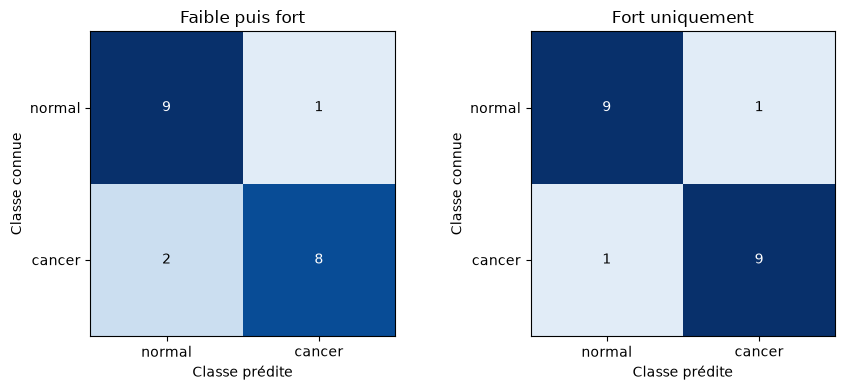

Écart de F1 cancer (semi-supervisé - supervisé) : -0.058
Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.


In [ ]:
comparaison_etape4 = pd.DataFrame(
    [mesures_semi, mesures_supervise],
    index=["Semi-supervisé : faible puis fort", "Supervisé : fort uniquement"],
).rename(columns={
    "F1": "F1 cancer",
    "Précision": "Précision cancer",
    "Rappel": "Rappel cancer",
    "F2": "F2 cancer",
})
display(comparaison_etape4.round(3))

matrices_etape4 = [confusion_semi, confusion_supervise]
titres_etape4 = ["Faible puis fort", "Fort uniquement"]
maximum_effectifs = max(matrice.max() for matrice in matrices_etape4)
figure, axes = plt.subplots(1, 2, figsize=(9, 4))

for axe, matrice, titre in zip(axes, matrices_etape4, titres_etape4):
    axe.imshow(matrice, cmap="Blues", vmin=0, vmax=maximum_effectifs)
    axe.set_xticks([0, 1], ["normal", "cancer"])
    axe.set_yticks([0, 1], ["normal", "cancer"])
    axe.set_xlabel("Classe prédite")
    axe.set_ylabel("Classe connue")
    axe.set_title(titre)

    for ligne in range(2):
        for colonne in range(2):
            couleur = "white" if matrice[ligne, colonne] > maximum_effectifs / 2 else "black"
            axe.text(
                colonne, ligne, str(matrice[ligne, colonne]),
                ha="center", va="center", color=couleur
            )

plt.tight_layout()
plt.show()

ecart_f1 = mesures_semi["F1"] - mesures_supervise["F1"]
print(f"Écart de F1 cancer (semi-supervisé - supervisé) : {ecart_f1:+.3f}")

if ecart_f1 > 0:
    print("Sur ce test, le modèle semi-supervisé obtient un F1 cancer supérieur.")
elif ecart_f1 < 0:
    print("Sur ce test, le modèle supervisé obtient un F1 cancer supérieur.")
else:
    print("Sur ce test, les deux modèles obtiennent le même F1 cancer.")


Reperage d'un  surapprentissage

,Modèle,Jeu,Images,Accuracy,F1 cancer,Précision cancer,Rappel cancer,F2 cancer
0,Semi-supervisé,Train fort,63,0.968,0.969,0.969,0.969,0.969
1,Semi-supervisé,Test fort,20,0.850,0.842,0.889,0.800,0.816
2,Supervisé,Train fort,63,0.952,0.952,0.968,0.938,0.943
3,Supervisé,Test fort,20,0.900,0.900,0.900,0.900,0.900


Semi-supervisé : écart train - test = +11.8 points d'accuracy et +15.2 points de F2 cancer.
Supervisé : écart train - test = +5.2 points d'accuracy et +4.3 points de F2 cancer.


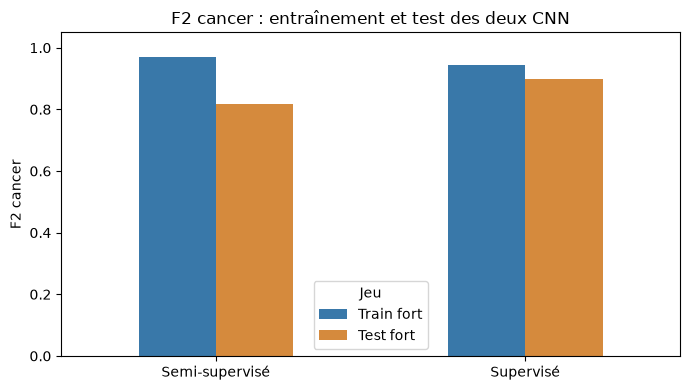

In [ ]:
chargeur_train_evaluation = DataLoader(
    chargeur_fort.dataset,
    batch_size=taille_lot_etape4,
    shuffle=False,
    generator=torch.Generator().manual_seed(42),
)

resultats_train_test = []
for nom, cnn, mesures_test in [
    ("Semi-supervisé", modele_semi, mesures_semi),
    ("Supervisé", modele_supervise, mesures_supervise),
]:
    mesures_train, _ = evaluer_cnn(cnn, chargeur_train_evaluation)

    resultats_train_test.append({
        "Modèle": nom, "Jeu": "Train fort",
        "Images": len(chargeur_train_evaluation.dataset), **mesures_train,
    })
    resultats_train_test.append({
        "Modèle": nom, "Jeu": "Test fort",
        "Images": len(chargeur_test.dataset), **mesures_test,
    })

comparaison_train_test = pd.DataFrame(resultats_train_test)
display(comparaison_train_test.rename(columns={
    "F1": "F1 cancer", "Précision": "Précision cancer",
    "Rappel": "Rappel cancer", "F2": "F2 cancer",
}).round(3))

for nom in ["Semi-supervisé", "Supervisé"]:
    scores = comparaison_train_test.loc[
        comparaison_train_test["Modèle"] == nom
    ].set_index("Jeu")
    ecart_accuracy = 100 * (scores.loc["Train fort", "Accuracy"] - scores.loc["Test fort", "Accuracy"])
    ecart_f2 = 100 * (scores.loc["Train fort", "F2"] - scores.loc["Test fort", "F2"])
    print(f"{nom} : écart train - test = {ecart_accuracy:+.1f} points d'accuracy et {ecart_f2:+.1f} points de F2 cancer.")

scores_f2_train_test = comparaison_train_test.pivot(
    index="Modèle", columns="Jeu", values="F2"
).reindex(index=["Semi-supervisé", "Supervisé"], columns=["Train fort", "Test fort"])
axe = scores_f2_train_test.plot.bar(
    figsize=(7, 4), color=["#3978A9", "#D58A3D"], rot=0,
)
axe.set_title("F2 cancer : entraînement et test des deux CNN")
axe.set_xlabel("")
axe.set_ylabel("F2 cancer")
axe.set_ylim(0, 1.05)
axe.legend(title="Jeu")
plt.tight_layout()
plt.show()

L'ecart entre lees metriques traine et test indique un possible surapprentissage du modèle semi-supervisé

Durée écoulée depuis le début du notebook jusqu'à cette cellule.

Affichage de la durée en secondes et en minutes.

In [ ]:
duree_notebook = time.perf_counter() - debut_notebook

print(f"Durée totale : {duree_notebook:.1f} secondes")
print(f"Soit : {duree_notebook / 60:.2f} minutes")

Durée totale : 154.2 secondes
Soit : 2.57 minutes


## Conclusion
Le fait d'avoir beaucoup d'images non labellisées et peu d'images labellisées justifie de tester un entraînement semi-supervisé.
Cependant, les résultats montrent ici que le CNN supervisé est plus performant. Dans cette configuration et sur ce test, le semi-supervisé n'apporte pas d'amélioration.

Mesure du temps nécessaire pour lire, prétraiter et attribuer un label à 1 000 images avec le CNN supervisé déjà entraîné. Les images sont traitées par lots de 16. La cellule affiche la durée mesurée et une estimation pour 4 millions d'images, en supposant une vitesse comparable sur la même machine. L'entraînement n'est pas inclus.

Le même prétraitement avec égalisation est utilisé. La durée et le pic de RAM du processus Python sont mesurés séparément de la création du modèle.

In [ ]:
chemins_mesure = donnees_sans_label["chemin"].sample(
    n=min(1000, len(donnees_sans_label)),
    random_state=42,
).tolist()

with mesurer_ressources("Prédiction des images finales", "Traitement final"):
    modele_supervise.eval()
    labels_predits_mesure = []

    with torch.no_grad():
        for debut in range(0, len(chemins_mesure), 16):
            chemins_lot = chemins_mesure[debut:debut + 16]
            images_lot = []

            for chemin in chemins_lot:
                image = read_image(
                    str(dossier_dataset / chemin),
                    mode=ImageReadMode.RGB,
                )
                images_lot.append(pretraitement(image))

            lot = torch.stack(images_lot).to(appareil_etape4)
            predictions = modele_supervise(lot).argmax(dim=1)
            labels_predits_mesure.extend(predictions.cpu().tolist())

duree_labellisation = mesures_ressources["Prédiction des images finales"]["Durée (s)"]
nombre_images = len(labels_predits_mesure)

heures_estimees = (
    duree_labellisation / nombre_images * 4_000_000 / 3600
)

print("Machine utilisée :", appareil_etape4)
print("Nombre d'images traitées :", nombre_images)
print(f"Durée mesurée : {duree_labellisation:.1f} secondes")
print(f"Estimation pour 4 millions : {heures_estimees:.1f} heures")

Machine utilisée : cpu
Nombre d'images traitées : 1000
Durée mesurée : 8.1 secondes
Estimation pour 4 millions : 9.0 heures


### Durée et RAM pour la création du modèle et traitement final

Afficher le détail de `mesures_ressources`, puis un bilan en deux lignes.

- La création regroupe les opérations mesurées : prétraitement, deux extractions, essais de clustering, recherches d'hyperparamètres, entraînements et leurs évaluations.
- Le traitement final porte sur l'échantillon de 1 000 images de la cellule précédente.

Dans chaque groupe, les durées mesurées sont additionnées et la RAM retenue est le maximum observé pour le processus Python.

In [ ]:
details_ressources = pd.DataFrame(mesures_ressources.values()).rename(columns={
    "RAM au départ (Mio)": "RAM totale avant la cellule (Mio)",
    "Pic RAM (Mio)": "RAM totale maximale pendant la cellule (Mio)",
    "Hausse maximale (Mio)": "Augmentation maximale pendant la cellule (Mio)",
})
display(details_ressources.round(2))

bilan_ressources = details_ressources.groupby("Groupe", sort=False).agg({
    "Durée (s)": "sum",
    "RAM totale maximale pendant la cellule (Mio)": "max",
}).rename(columns={
    "RAM totale maximale pendant la cellule (Mio)": "RAM totale maximale (Mio)",
})
bilan_ressources["Durée (min)"] = bilan_ressources["Durée (s)"] / 60
display(bilan_ressources.round(2))

,Groupe,Opération,Durée (s),RAM totale avant la cellule (Mio),RAM totale maximale pendant la cellule (Mio),Augmentation maximale pendant la cellule (Mio)
0,Création du modèle,Préparation et égalisation des images,4.04,462.40,1853.94,1391.54
1,Création du modèle,Chargement du modèle d’extraction,0.11,1854.41,1937.75,83.34
2,Création du modèle,Extraction des embeddings layer4,6.67,1937.82,2075.57,137.76
3,Création du modèle,Essai des embeddings layer3,5.52,2049.78,2093.49,43.71
4,Création du modèle,Création du tableau de features,0.06,2015.38,2015.38,0.00
5,Création du modèle,Sauvegarde du tableau CSV,0.30,2012.09,2026.77,14.68
6,Création du modèle,Lecture du CSV et séparation des ensembles,0.08,2014.90,2040.55,25.65
7,Création du modèle,Standardisation des embeddings,0.01,2040.54,2045.05,4.52
8,Création du modèle,PCA des embeddings,0.02,2045.07,2048.22,3.14
9,Création du modèle,Clustering K-Means,0.01,2048.21,2049.86,1.64


,Durée (s),RAM totale maximale (Mio),Durée (min)
Groupe,,,
Création du modèle,146.91,3234.08,2.45
Traitement final,8.09,3225.18,0.13
